# Notebook 05: Error Analysis and Diagnostics

**Deskripsi:** Notebook ini memuat model ML terbaik yang telah diserialisasi di `models/best_ml_model.joblib`, memproses prediksi pada set uji (`test.csv`), menghasilkan laporan metrik klasifikasi per kelas emosi secara detail, merender visualisasi **Matriks Konfusi 5x5 yang Dinormalisasi** untuk mendeteksi tumpang tindih emosi, dan mengekstrak contoh ulasan salah prediksi (seperti bias sarkasme dan kegagalan negasi) untuk keperluan studi kasus linguistik laporan paper.

In [16]:
import sys
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Tambahkan path parent directory agar modul 'src' bisa diimpor
sys.path.append(os.path.abspath('../'))
from src.evaluation import plot_normalized_confusion_matrix, extract_misclassifications

# Buat direktori laporan gambar jika belum ada
os.makedirs('../reports/figures', exist_ok=True)
print("Modul diagnostik berhasil dimuat!")

Modul diagnostik berhasil dimuat!


## 1. Memuat Model Terbaik, Fitur Set Uji, dan Teks Uji Asli

In [17]:
# 1. Muat payload model terbaik
model_payload = joblib.load('../models/best_ml_model.joblib')
best_model = model_payload['model']
best_feat_type = model_payload['feature_type']

print(f"Model Terbaik yang Dimuat : {best_model.__class__.__name__}")
print(f"Tipe Fitur Terpilih        : {best_feat_type}")

# 2. Muat set ulasan uji asli
test_df = pd.read_csv('../data/processed/test.csv')

# 3. Muat matriks fitur uji numerik yang sesuai
features = joblib.load('../data/processed/extracted_features.joblib')

test_feat_map = {
    'tfidf': 'X_test_tfidf',
    'w2v_average': 'X_test_w2v_avg',
    'w2v_weighted': 'X_test_w2v_weighted'
}

X_test = features[test_feat_map[best_feat_type]]
y_test = np.array(features['y_test']).astype(str)

print(f"Dimensi Fitur Uji dimuat : {X_test.shape}")
print(f"Dimensi Label Uji dimuat : {y_test.shape}")

Model Terbaik yang Dimuat : LinearSVC
Tipe Fitur Terpilih        : tfidf
Dimensi Fitur Uji dimuat : (2738, 15654)
Dimensi Label Uji dimuat : (2738,)


## 2. Klasifikasi dan Laporan Metrik Detail Per-Kelas

Kita mencetak laporan klasifikasi detail yang menampilkan **Precision, Recall, dan F1-Score** untuk kelima kelas emosi (*Joy, Anger, Sadness, Fear, Disgust*) pada data uji.

In [18]:
y_pred = best_model.predict(X_test)
classes = ['joy', 'anger', 'sadness', 'fear', 'disgust']

print("--- LAPORAN KLASIFIKASI MODEL TERBAIK (TEST SET) ---")
print(classification_report(y_test, y_pred, target_names=classes))

--- LAPORAN KLASIFIKASI MODEL TERBAIK (TEST SET) ---
              precision    recall  f1-score   support

         joy       0.98      0.98      0.98       926
       anger       0.93      0.89      0.91       149
     sadness       0.90      0.94      0.92       247
        fear       0.99      0.99      0.99      1163
     disgust       0.92      0.90      0.91       253

    accuracy                           0.97      2738
   macro avg       0.94      0.94      0.94      2738
weighted avg       0.97      0.97      0.97      2738



## 3. Visualisasi 5x5 Normalized Confusion Matrix

Kita memplot matriks konfusi ternormalisasi untuk mendeteksi *class confusion* dan menyimpannya sebagai berkas gambar resolusi tinggi untuk paper.

Grafik Confusion Matrix disimpan ke: ../reports/figures/normalized_confusion_matrix.png


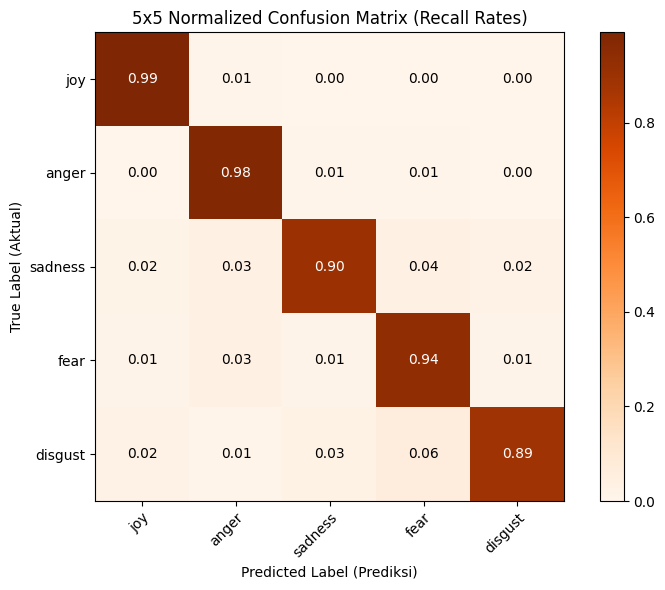

In [19]:
save_fig_path = '../reports/figures/normalized_confusion_matrix.png'
plot_normalized_confusion_matrix(y_test, y_pred, classes=classes, save_path=save_fig_path)

## 4. Ekstraksi Kasus Salah Prediksi untuk Analisis Leksikal kualitatif

Kita memanggil modul pembantu untuk melacak ulasan asli dari pengguna yang gagal didefinisikan secara benar oleh model.

### Kasus 1: Dampak Sarkasme (Aktual: Anger / Sadness -> Prediksi: Joy)
Kasus di mana model memprediksi kegembiraan karena mendeteksi kata kunci positif, padahal ulasan sebenarnya bernada marah atau kecewa.

In [20]:
extract_misclassifications(test_df, y_test, y_pred, target_true='anger', target_pred='joy', num_samples=3)

Menampilkan 3 dari 3 kasus salah prediksi (anger -> joy):
Review Asli : jelekkk, suka tiba tiba ada bug, suka keluar sendiri, lag terus loadingnya lama padahal jaringan oke oke aja
TF-IDF Text : jelekkk suka tiba tiba ada bug suka keluar sendiri lag terus loadingnya lama padahal jaring oke oke aja
W2V Text   : jelekkk suka tiba tiba ada bug suka keluar sendiri lag terus loadingnya lama padahal jaringan oke oke aja
--------------------------------------------------------------------------------
Review Asli : suka ngebug bangsat
TF-IDF Text : suka ngebug bangsat
W2V Text   : suka ngebug bangsat
--------------------------------------------------------------------------------
Review Asli : x apk julid jir, apa' julid tp seru si karna ada berita' baru yang seliweran tp tolong aktifin voice note biar bisa ketawa, marah, nangis plss🥰
TF-IDF Text : twitter apk julid jir apa julid tapi seru si karna ada berita baru seliwer tapi tolong aktifin voice note biar bisa ketawa marah nang plss
W2V Text

### Kasus 2: Dampak Tumpang Tindih Kosakata Keluhan (Aktual: Disgust -> Prediksi: Anger)
Ulasan yang aktualnya merupakan rasa muak/jijik terhadap konten atau bot, tetapi model mendeteksinya sebagai kemarahan umum.

In [21]:
extract_misclassifications(test_df, y_test, y_pred, target_true='disgust', target_pred='anger', num_samples=3)

Menampilkan 1 dari 1 kasus salah prediksi (disgust -> anger):
Review Asli : kenapa kok gak bisa login waktu dh masuk tiba tiba keluar sendiri bikin sebel tau gak, terus tiap lagi asik nonton video malah keluar sendiri, klo lama lama kayak gini mending ku uninstall aja deh bikin sebel semoga aplikasi nya cepat di perbaiki deh
TF-IDF Text : kenapa tidak bisa login waktu dh masuk tiba tiba keluar sendiri bikin kesal tau tidak terus tiap lagi asik nonton video malah keluar sendiri kalau lama lama kayak gin mending ku copot aja deh bikin kesal moga aplikasi nya cepat baik deh
W2V Text   : kenapa kok tidak bisa login waktu dh masuk tiba tiba keluar sendiri bikin kesal tau tidak terus tiap lagi asik nonton video malah keluar sendiri kalau lama lama kayak gini mending ku copot aja deh bikin kesal semoga aplikasi nya cepat di perbaiki deh
--------------------------------------------------------------------------------


### Kasus 3: Kegagalan Pengenalan Emosi Minoritas (Aktual: Fear -> Prediksi: Sadness)
Ulasan kecemasan data privasi yang terdeteksi sebagai kekecewaan karena adanya kata keluhan umum.

In [22]:
extract_misclassifications(test_df, y_test, y_pred, target_true='fear', target_pred='sadness', num_samples=3)

Menampilkan 3 dari 3 kasus salah prediksi (fear -> sadness):
Review Asli : apk aneh gw yang gapernah make akun pas mau dipake lagi malah ditangguhkan padahal sebelum jadi x engga pernah gini
TF-IDF Text : apk aneh gw gapernah make akun pas mau dipake lagi malah tangguh padahal belum jadi twitter engga pernah gin
W2V Text   : apk aneh gw yang gapernah make akun pas mau dipake lagi malah ditangguhkan padahal sebelum jadi twitter engga pernah gini
--------------------------------------------------------------------------------
Review Asli : Twitter semenjak dipegang oleh elon musk, penggunaan benar-benar tidak sebebas dulu, Twitter semakin rawan untuk terkena suspend karena alasan yang tidak jelas, bahkan dengan membeli centang biru juga tidak akan menjamin bahwa akun itu nantinya akan aman, bahkan untuk akun yang baru dibuat saja sudah terkena label temporer!
TF-IDF Text : twitter semenjak pegang elon musk guna benar benar tidak bebas dulu twitter makin rawan kena suspend karena alas tid

## 5. Uji Prediksi Kalimat Kustom (Demo Interaktif)

Di bawah ini adalah fungsi pembantu untuk memproses ulasan mentah kustom baru, mengekstrak fiturnya sesuai dengan representasi terbaik, dan memprediksi emosinya menggunakan model terbaik kita (`best_ml_model.joblib`).

Fungsi ini juga akan menampilkan probabilitas atau skor keputusan (*decision scores*) untuk setiap emosi.

In [23]:
import sys
import os
import joblib
import numpy as np
from gensim.models import Word2Vec

# Tambahkan path parent directory agar modul 'src' bisa diimpor
sys.path.append(os.path.abspath('../'))
from src.preprocessing import preprocess_for_tfidf, preprocess_for_word2vec

def predict_custom_emotion(text_input):
    # 1. Muat payload model terbaik
    model_payload = joblib.load('../models/best_ml_model.joblib')
    best_model = model_payload['model']
    best_feat_type = model_payload['feature_type']
    
    print(f"Model Terpilih        : {best_model.__class__.__name__} ({best_feat_type})")
    print(f"Teks Ulasan Masukan   : '{text_input}'")
    
    # 2. Pra-pengolahan dan Ekstraksi Fitur berdasarkan Tipe Fitur Terbaik
    if best_feat_type == 'tfidf':
        cleaned_text = preprocess_for_tfidf(text_input)
        print(f"Hasil Preprocessing   : '{cleaned_text}'")
        vectorizer = joblib.load('../models/tfidf_vectorizer.joblib')
        X_input = vectorizer.transform([cleaned_text])
        
    elif best_feat_type == 'w2v_average':
        cleaned_text = preprocess_for_word2vec(text_input)
        print(f"Hasil Preprocessing   : '{cleaned_text}'")
        w2v_model = Word2Vec.load('../models/custom_word2vec.model')
        words = cleaned_text.split()
        word_vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
        
        if len(word_vectors) > 0:
            X_input = np.mean(word_vectors, axis=0).reshape(1, -1)
        else:
            X_input = np.zeros((1, w2v_model.vector_size))
            print("[WARNING] Semua kata dalam kalimat adalah OOV (Out of Vocabulary).")
            
    elif best_feat_type == 'w2v_weighted':
        cleaned_text = preprocess_for_word2vec(text_input)
        print(f"Hasil Preprocessing   : '{cleaned_text}'")
        w2v_model = Word2Vec.load('../models/custom_word2vec.model')
        w2v_tfidf = joblib.load('../models/w2v_tfidf_vectorizer.joblib')
        
        words = cleaned_text.split()
        word_vectors = []
        weights = []
        
        tfidf_weights = w2v_tfidf.transform([cleaned_text]).toarray()[0]
        feature_names = w2v_tfidf.get_feature_names_out()
        word_to_weight = {word: tfidf_weights[idx] for idx, word in enumerate(feature_names) if tfidf_weights[idx] > 0}
        
        for word in words:
            if word in w2v_model.wv:
                word_vectors.append(w2v_model.wv[word])
                weights.append(word_to_weight.get(word, 1.0))
                
        if len(word_vectors) > 0:
            X_input = np.average(word_vectors, axis=0, weights=weights).reshape(1, -1)
        else:
            X_input = np.zeros((1, w2v_model.vector_size))
            print("[WARNING] Semua kata dalam kalimat adalah OOV (Out of Vocabulary).")
            
    else:
        raise ValueError(f"Tipe fitur tidak dikenal: {best_feat_type}")
        
    # 3. Prediksi Emosi
    pred_label = best_model.predict(X_input)[0]
    
    # 4. Prediksi Probabilitas jika didukung oleh model
    pred_proba = None
    if hasattr(best_model, "predict_proba"):
        pred_proba = best_model.predict_proba(X_input)[0]
    elif hasattr(best_model, "decision_function"):
        scores = best_model.decision_function(X_input)[0]
        exp_scores = np.exp(scores - np.max(scores))
        pred_proba = exp_scores / exp_scores.sum()
        
    classes = best_model.classes_
    print("\n--- HASIL PREDIKSI EMOSI ---")
    print(f"Emosi Terdeteksi      : {pred_label.upper()}")
    
    if pred_proba is not None:
        print("Probabilitas Distribusi:")
        for cls, prob in zip(classes, pred_proba):
            print(f"  {cls:<8}: {prob:.2%}")
            
    return pred_label

# Uji Coba Prediksi Beberapa Kalimat Ulasan Baru
print("CONTOH 1:")
predict_custom_emotion("aplikasinya jelek banget, tiap buka loading terus sering force close bikin emosi!")
print("\n" + "="*50 + "\n")
print("CONTOH 2:")
predict_custom_emotion("wah gokil sih fitur barunya keren banget memudahkan saya bersosialisasi makasih ya dev!")
print("\n" + "="*50 + "\n")
print("CONTOH 3:")
predict_custom_emotion("khawatir banget sama kebocoran data privasi apalagi ada berita akun di hack orang lain")


CONTOH 1:
Model Terpilih        : LinearSVC (tfidf)
Teks Ulasan Masukan   : 'aplikasinya jelek banget, tiap buka loading terus sering force close bikin emosi!'
Hasil Preprocessing   : 'aplikasi jelek banget tiap buka loading terus sering force close bikin emosi'

--- HASIL PREDIKSI EMOSI ---
Emosi Terdeteksi      : ANGER
Probabilitas Distribusi:
  anger   : 98.43%
  disgust : 0.40%
  fear    : 0.21%
  joy     : 0.56%
  sadness : 0.40%


CONTOH 2:


Model Terpilih        : LinearSVC (tfidf)
Teks Ulasan Masukan   : 'wah gokil sih fitur barunya keren banget memudahkan saya bersosialisasi makasih ya dev!'
Hasil Preprocessing   : 'wah gokil fitur baru keren banget mudah sosial makasih ya dev'

--- HASIL PREDIKSI EMOSI ---
Emosi Terdeteksi      : JOY
Probabilitas Distribusi:
  anger   : 6.67%
  disgust : 8.47%
  fear    : 13.24%
  joy     : 65.65%
  sadness : 5.98%


CONTOH 3:
Model Terpilih        : LinearSVC (tfidf)
Teks Ulasan Masukan   : 'khawatir banget sama kebocoran data privasi apalagi ada berita akun di hack orang lain'
Hasil Preprocessing   : 'khawatir banget sama bocor data privasi apalagi ada berita akun hack orang lain'

--- HASIL PREDIKSI EMOSI ---
Emosi Terdeteksi      : FEAR
Probabilitas Distribusi:
  anger   : 4.81%
  disgust : 5.34%
  fear    : 80.40%
  joy     : 5.46%
  sadness : 4.00%


np.str_('fear')